Semilla fijada en: 42
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Transformers version: 4.57.3
Torch version: 2.9.0+cu126
Scikit-learn version: 1.6.1
Entorno configurado para reproducibilidad.
Mounted at /content/drive
Directorio de trabajo: /content/drive/MyDrive/TFG_Data

>>> Procesando IMDB: IMDB.csv...
   - Dimensiones originales: (50000, 2)
   - Aplicando limpieza de texto...

>>> Procesando AMAZON: Amazon_train.csv...
   - Balanceado a 25000 por clase.

>>> Procesando AMAZON: Amazon_test.csv...
   - Balanceado a 5000 por clase.

>>> Procesando YELP: Yelp_train.csv...
   - Balanceado a 25000 por clase.

>>> Procesando YELP: Yelp_test.csv...
   - Balanceado a 5000 por clase.

 Guardando archivos procesados...
   -> Guardado: IMDB_train.csv (25000 filas)
   -> Guardado: IMDB_test.csv (25000 filas)
   -> Guardado: AMAZON_train.csv (50000 filas)
   -> Guardado: AMAZON_test.csv (10000 filas)
   -> Guardado: YELP_train.csv (50000 filas)
   -> Guardado: YELP_test.c

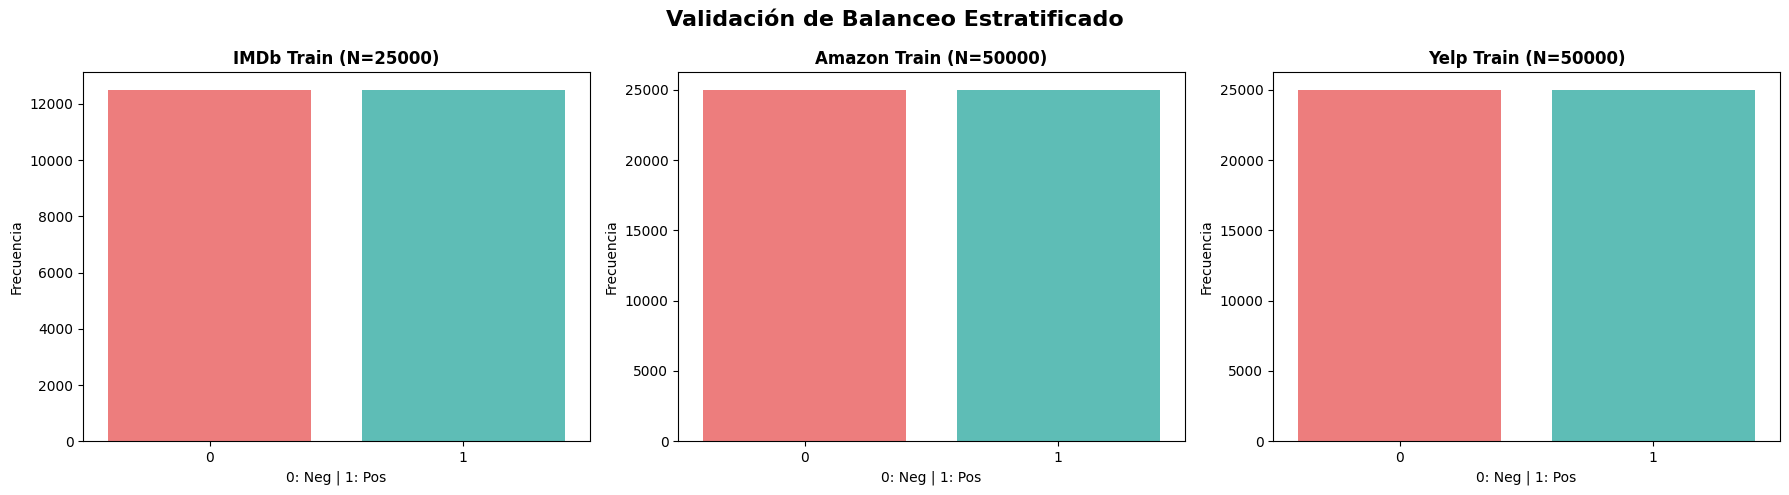


 Proceso completado exitosamente


In [ ]:
#
# PREPROCESAMIENTO
#

# Preprocesamiento ETL (Extract, Transform, Load)
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from google.colab import drive
import warnings
import random
import torch
import sys
import transformers
import sklearn

def set_seed(seed=42):
    """
    Fija las semillas aleatorias para reproducibilidad.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Semilla fijada en: {seed}")

# Fijación de semilla
set_seed(42)

# Versiones
print(f"Python version: {sys.version}")
print(f"Transformers version: {transformers.__version__}")
print(f"Torch version: {torch.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print("Entorno configurado para reproducibilidad.")

# Configuración
warnings.filterwarnings('ignore', category=FutureWarning)

# Montaje condicional del drive
try:
    drive.mount('/content/drive', force_remount=False)
except:
    print("Drive ya montado previamente")

BASE_PATH = "/content/drive/MyDrive/TFG_Data"
RAW_PATH = f"{BASE_PATH}/RAW"
PROCESSED_PATH = f"{BASE_PATH}/PROCESSED"

# Check: Se crea la carpeta de procesados si no existe
!mkdir -p "$PROCESSED_PATH"

print(f"Directorio de trabajo: {BASE_PATH}")

# PIPELINE DE LIMPIEZA DE TEXTO
def clean_text_pipeline(text):
    """
    Normalización de texto para modelos Transformer
    """
    if not isinstance(text, str):
        return ""

    # Conversión básica
    text = str(text)

    # Eliminación de HTML
    text = re.sub(r'<br\s*/?>', ' ', text)  # <br>, <br/>, <br />
    text = re.sub(r'<.*?>', '', text)       # Resto de tags

    # Eliminación de URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Limpieza de espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# PROCESADOR DE IMDB
def process_imdb(file_name="IMDB.csv"):
    print(f"\n>>> Procesando IMDB: {file_name}...")
    file_path = f"{RAW_PATH}/{file_name}"

    # Lectura
    df = pd.read_csv(file_path)
    print(f"   - Dimensiones originales: {df.shape}")

    # Normalización de columnas
    df = df.rename(columns={'review': 'text'})

    # Codificación: 'positive'->1, 'negative'->0
    df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

    # División Train/Test Estratificada (50/50 según Maas et al.)
    df_train, df_test = train_test_split(
        df,
        test_size=0.5,
        random_state=42,
        stratify=df['label']
    )

    # Limpieza
    print("   - Aplicando limpieza de texto...")
    df_train['text'] = df_train['text'].apply(clean_text_pipeline)
    df_test['text'] = df_test['text'].apply(clean_text_pipeline)

    # Selección final
    return (df_train[['text', 'label']],
            df_test[['text', 'label']])

# PROCESADOR DE AMAZON
def process_amazon(file_name, sample_size=25000):
    print(f"\n>>> Procesando AMAZON: {file_name}...")

    # Headers
    df = pd.read_csv(
        f"{RAW_PATH}/{file_name}",
        header=None,
        names=['raw_label', 'title', 'review']
    )

    # Feature engineering: título + texto
    df['text'] = df['title'].fillna('') + ". " + df['review'].fillna('')

    # Codificación: 1->0, 2->1
    df['label'] = df['raw_label'].map({1: 0, 2: 1})

    # Balanceo
    try:
        df_bal = df.groupby('label', group_keys=False).sample(
            n=sample_size,
            random_state=42
        )
        print(f"   - Balanceado a {sample_size} por clase.")
    except ValueError:
        print("   ! Aviso: Dataset pequeño, se toma todo.")
        df_bal = df

    # Limpieza
    df_bal['text'] = df_bal['text'].apply(clean_text_pipeline)
    return df_bal[['text', 'label']]

# PROCESADOR DE YELP
def process_yelp(file_name, sample_size=25000):
    print(f"\n>>> Procesando YELP: {file_name}...")

    # Headers
    df = pd.read_csv(
        f"{RAW_PATH}/{file_name}",
        header=None,
        names=['raw_label', 'text']
    )

    # Codificación: 1->0, 2->1
    df['label'] = df['raw_label'].map({1: 0, 2: 1})

    # Balanceo
    try:
        df_bal = df.groupby('label', group_keys=False).sample(
            n=sample_size,
            random_state=42
        )
        print(f"   - Balanceado a {sample_size} por clase.")
    except ValueError:
        print("   ! Aviso: Dataset pequeño, se toma todo.")
        df_bal = df

    # Limpieza
    df_bal['text'] = df_bal['text'].apply(clean_text_pipeline)
    return df_bal[['text', 'label']]

# EJECUCIÓN
# Procesar IMDb
imdb_train, imdb_test = process_imdb("IMDB.csv")

# Procesar Amazon
amazon_train = process_amazon("Amazon_train.csv", sample_size=25000)
amazon_test = process_amazon("Amazon_test.csv", sample_size=5000)

# Procesar Yelp
yelp_train = process_yelp("Yelp_train.csv", sample_size=25000)
yelp_test = process_yelp("Yelp_test.csv", sample_size=5000)

# GUARDADO
print("\n Guardando archivos procesados...")
datasets_final = {
    "IMDB_train": imdb_train,
    "IMDB_test": imdb_test,
    "AMAZON_train": amazon_train,
    "AMAZON_test": amazon_test,
    "YELP_train": yelp_train,
    "YELP_test": yelp_test
}

for name, df in datasets_final.items():
    path = f"{PROCESSED_PATH}/{name}.csv"
    df.to_csv(path, index=False)
    print(f"   -> Guardado: {name}.csv ({len(df)} filas)")

# GRÁFICO DE VALIDACIÓN
print("\n Generando gráfica de validación...")
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Paleta de colores
palette = ["#FF6B6B", "#4ECDC4"]

# Gráficos con sintaxis actualizada (hue explícito)
sns.countplot(
    data=imdb_train,
    x='label',
    hue='label',
    ax=ax[0],
    palette=palette,
    legend=False
)
ax[0].set_title(f"IMDb Train (N={len(imdb_train)})", fontsize=12, fontweight='bold')
ax[0].set_xlabel("0: Neg | 1: Pos")
ax[0].set_ylabel("Frecuencia")

sns.countplot(
    data=amazon_train,
    x='label',
    hue='label',
    ax=ax[1],
    palette=palette,
    legend=False
)
ax[1].set_title(f"Amazon Train (N={len(amazon_train)})", fontsize=12, fontweight='bold')
ax[1].set_xlabel("0: Neg | 1: Pos")
ax[1].set_ylabel("Frecuencia")

sns.countplot(
    data=yelp_train,
    x='label',
    hue='label',
    ax=ax[2],
    palette=palette,
    legend=False
)
ax[2].set_title(f"Yelp Train (N={len(yelp_train)})", fontsize=12, fontweight='bold')
ax[2].set_xlabel("0: Neg | 1: Pos")
ax[2].set_ylabel("Frecuencia")

plt.suptitle("Validación de Balanceo Estratificado", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Proceso completado exitosamente")